In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:

df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:


df.shape

(1436, 11)

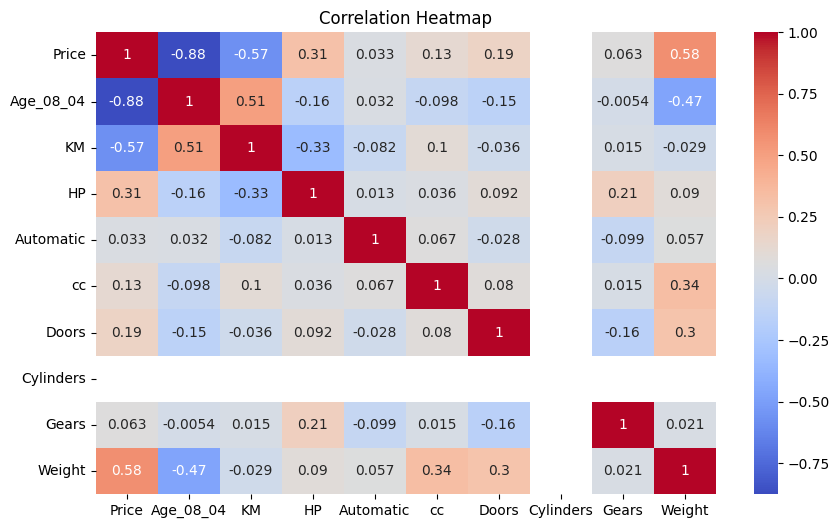

In [ ]:

plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Fuel_Type', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
                               # Visualizing correlation between variables using heatmap

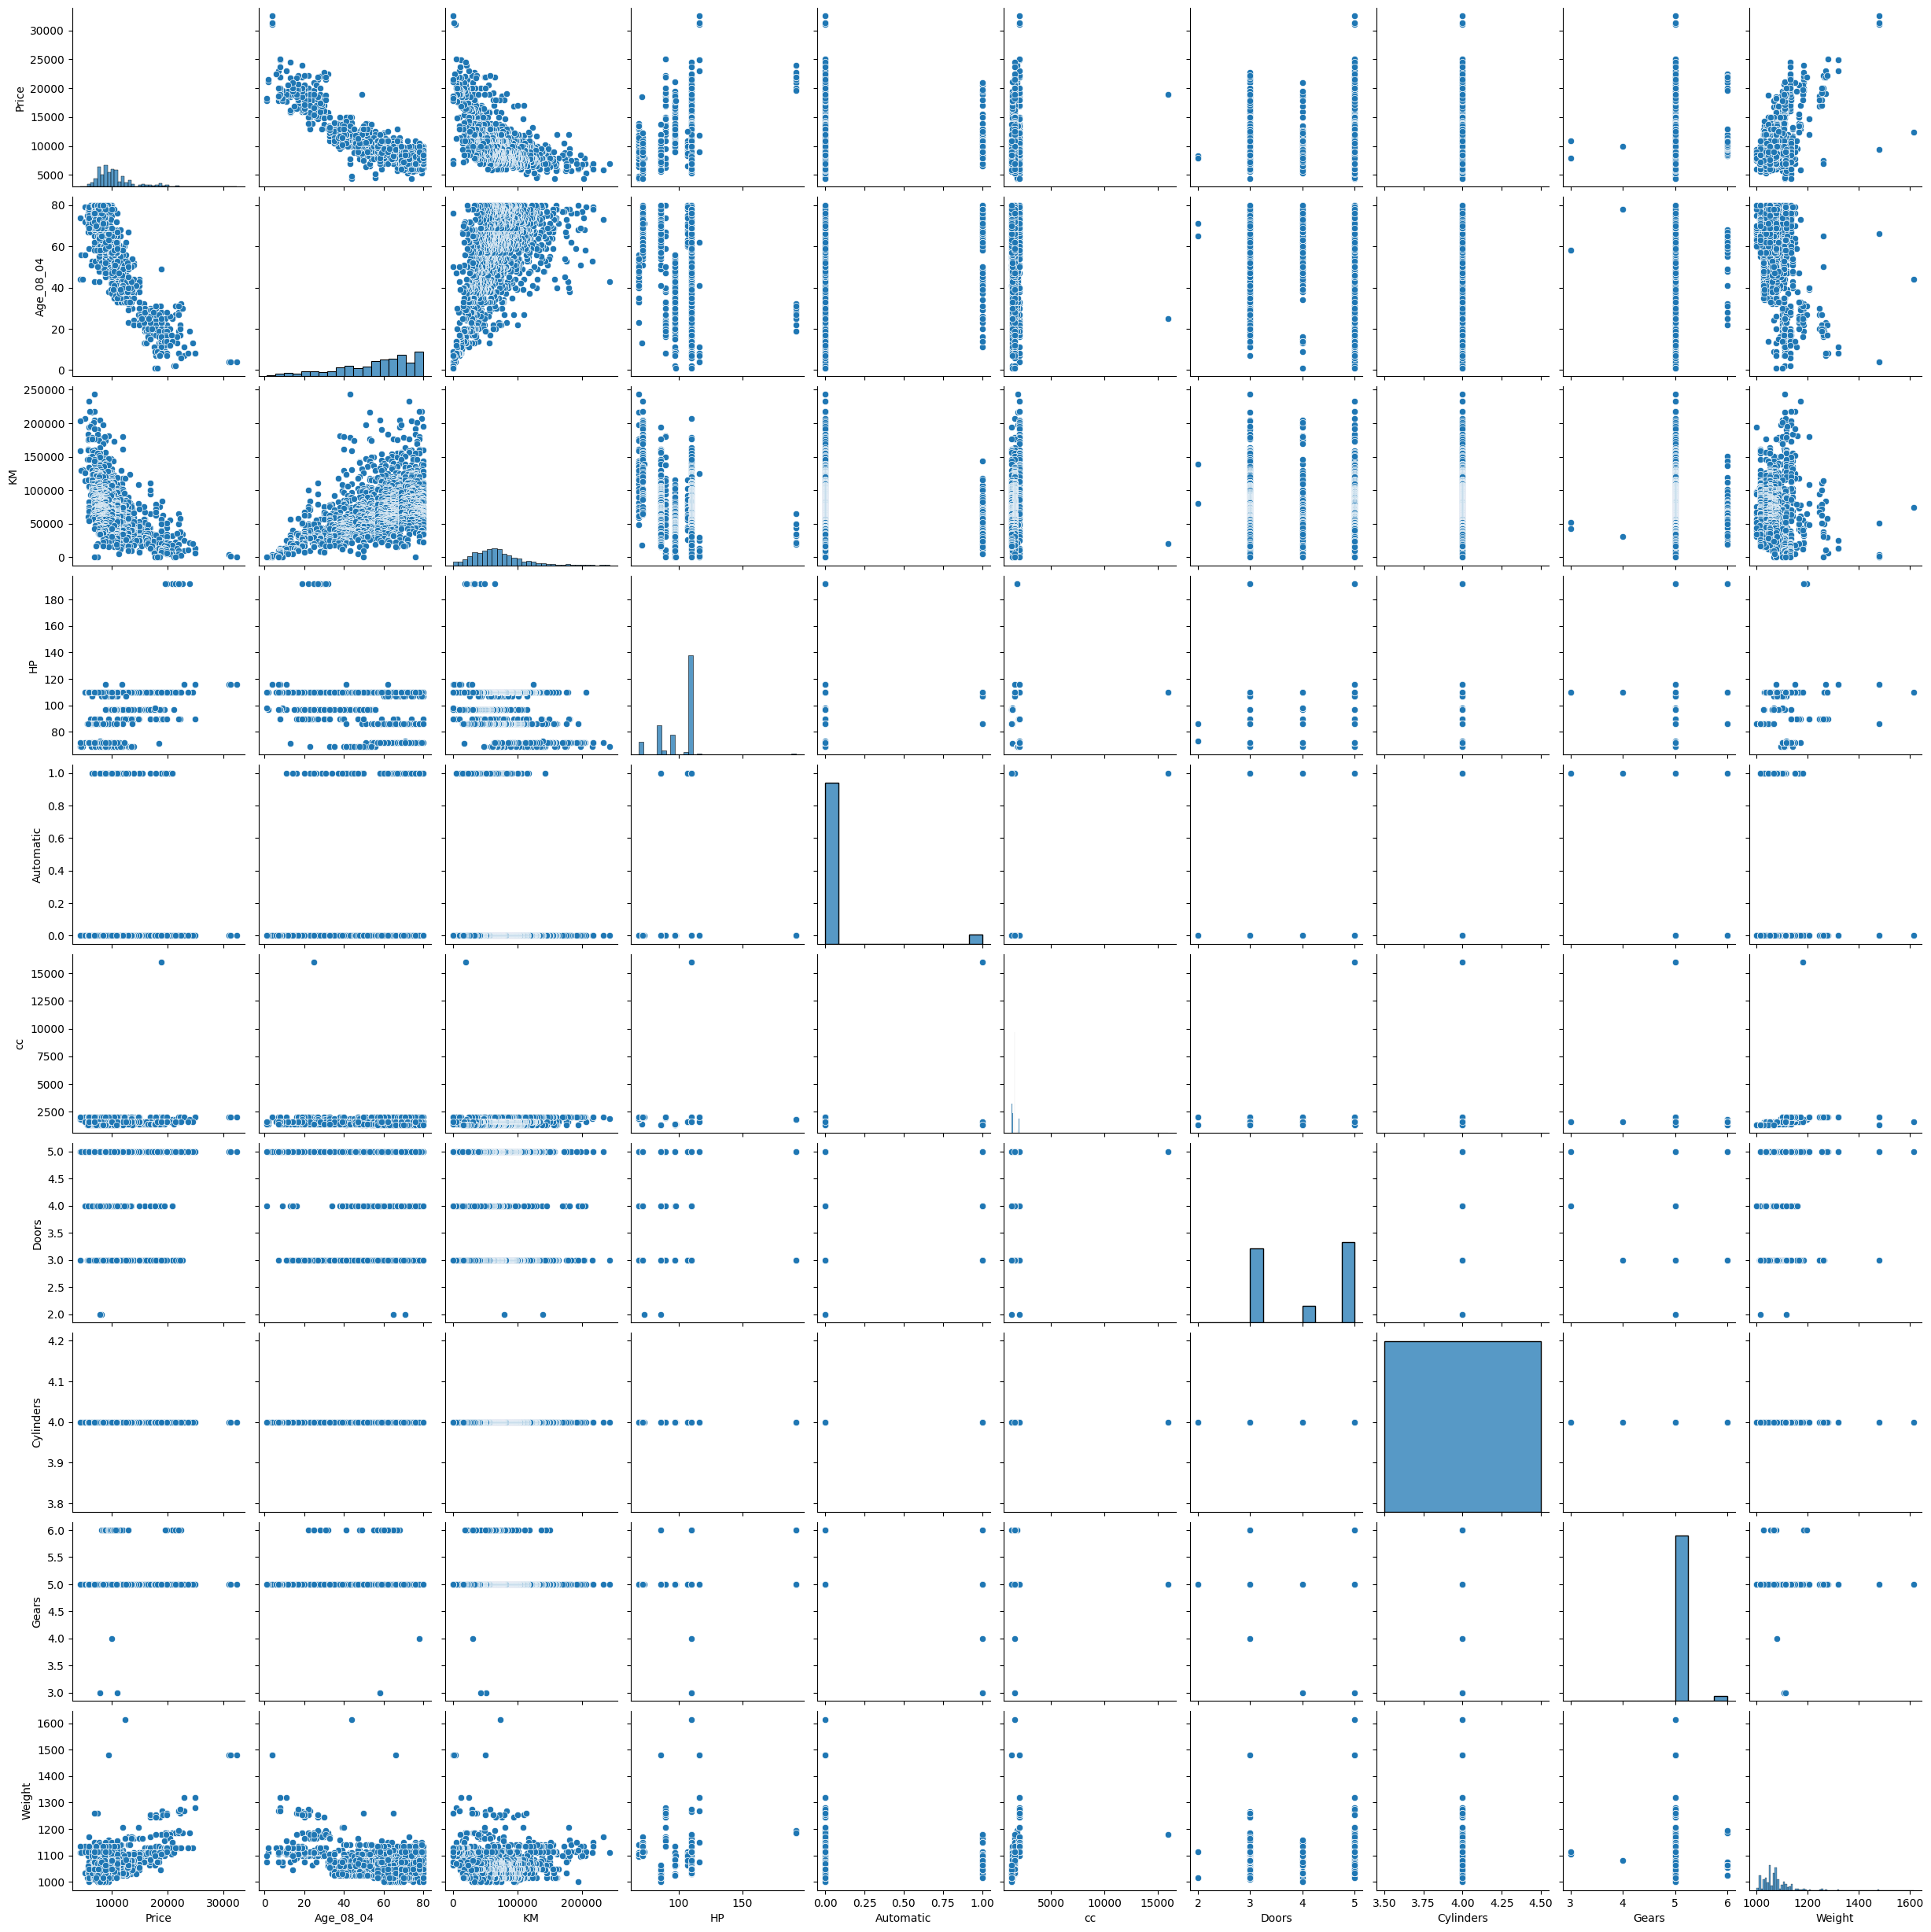

In [ ]:
sns.pairplot(df)
plt.show()
                    # Visualizing pairwise relationships between features

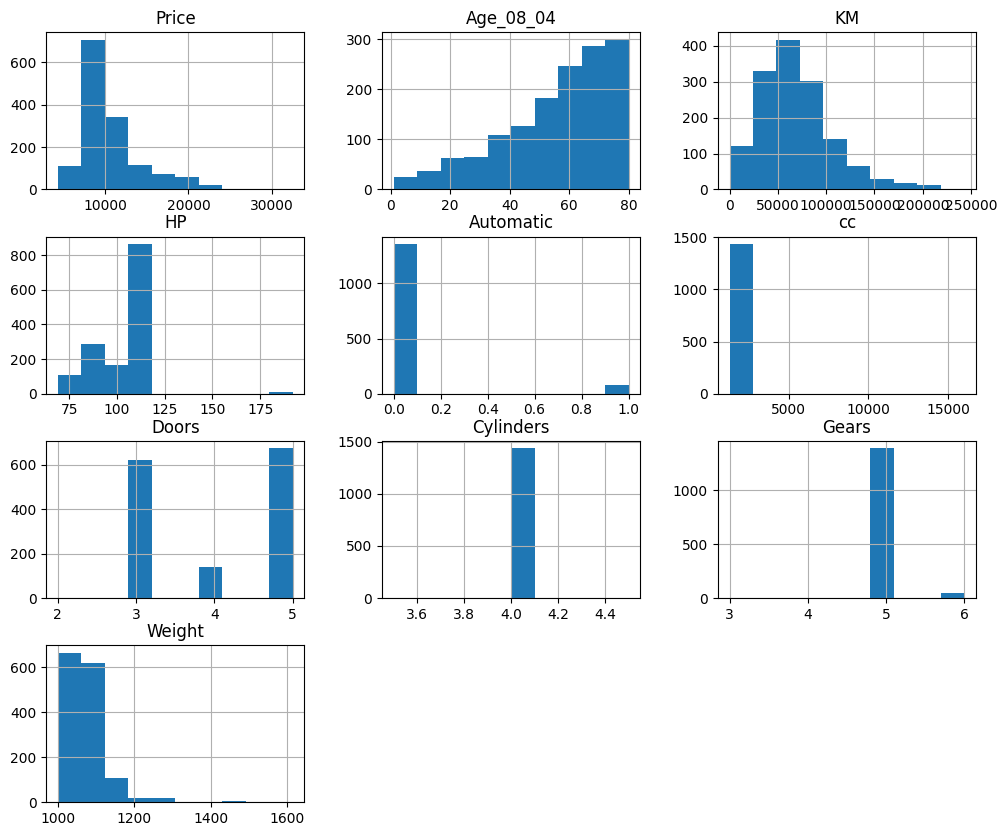

In [ ]:
df.hist(figsize=(12,10))
plt.show()
           # Plotting distribution of all numerical features

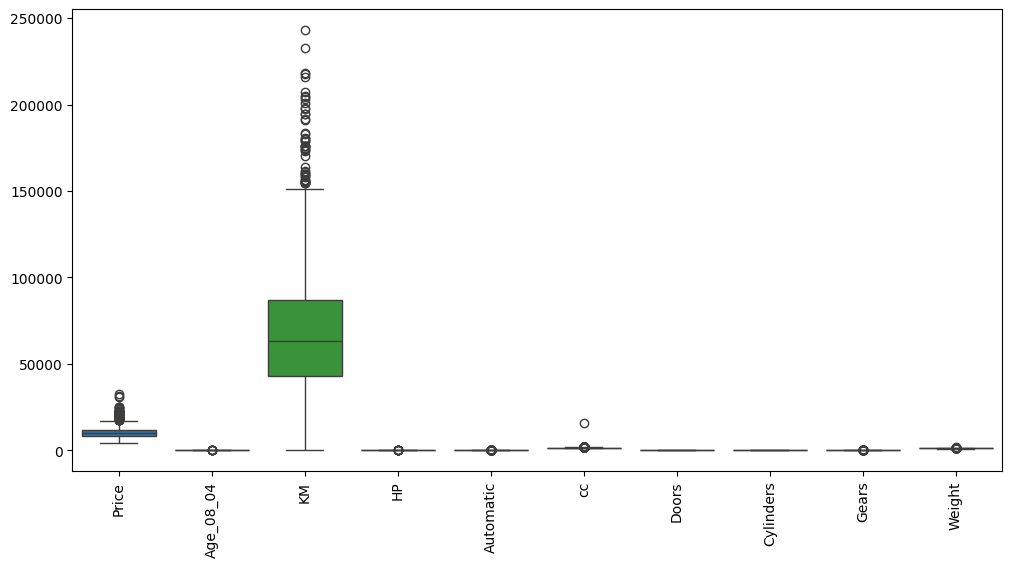

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()
                   # Detecting outliers in the dataset using boxplot

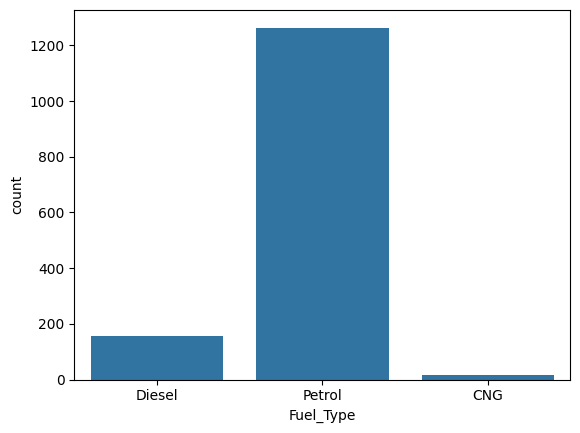

In [ ]:
sns.countplot(x='Fuel_Type', data=df)
plt.show()
            # Visualizing count of different fuel types

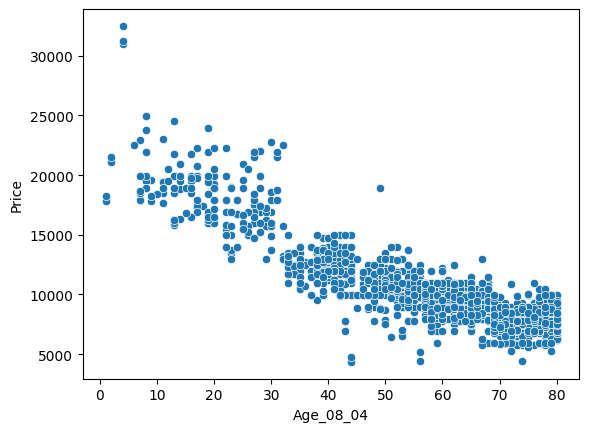

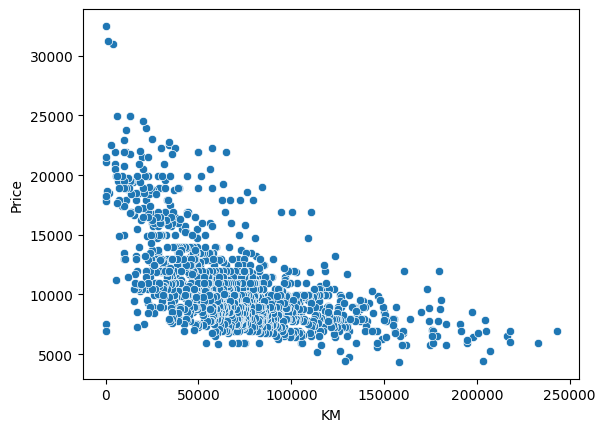

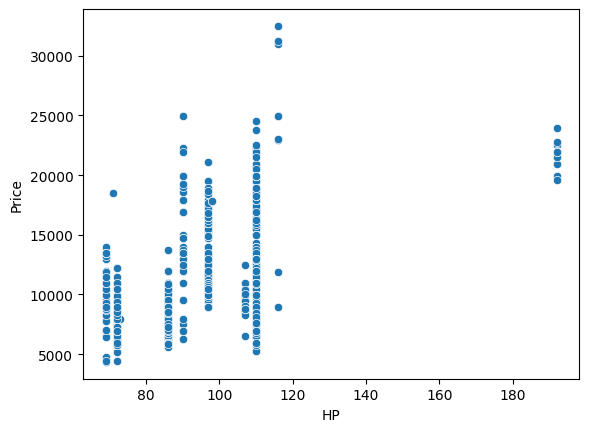

In [ ]:
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.show()

sns.scatterplot(x='KM', y='Price', data=df)
plt.show()

sns.scatterplot(x='HP', y='Price', data=df)
plt.show()
                       # Analyzing relationship between important features and target variable (Price)

EDA Analysis:

- Age increases → Price decreases
- KM increases → Price decreases
- HP increases → Price increases
- Diesel cars tend to have higher prices



In [ ]:
le = LabelEncoder()
df['Fuel_Type_Encoded'] = le.fit_transform(df['Fuel_Type'])
display(df.head())
                        # Encoding categorical variable 'FuelType' into numerical values

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Encoded
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165,1
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165,1
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165,1
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165,1
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170,1


In [ ]:
X = df[['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Encoded']]
y = df['Price']
display(X.head())
display(y.head())

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Encoded
0,23,46986,90,0,2000,3,4,5,1165,1
1,23,72937,90,0,2000,3,4,5,1165,1
2,24,41711,90,0,2000,3,4,5,1165,1
3,26,48000,90,0,2000,3,4,5,1165,1
4,30,38500,90,0,2000,3,4,5,1170,1


,Price
0,13500
1,13750
2,13950
3,14950
4,13750


In [ ]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model 1 - Using all features

In [ ]:
# Safety check
print(df.head())
print(df.dtypes)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully")
print("Sample predictions:", y_pred[:5])

   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  Fuel_Type_Encoded  
0      5    1165                  1  
1      5    1165                  1  
2      5    1165                  1  
3      5    1165                  1  
4      5    1170                  1  
Price                 int64
Age_08_04             int64
KM                    int64
Fuel_Type            object
HP                    int64
Automatic             int64
cc                    int64
Doors                 int64
Cylinders             int64
Gears                 int64
Weight           

In [ ]:
print("Model 1 R2:", r2_score(y_test, y_pred))

Model 1 R2: 0.8428476112018006


In [ ]:
# Model 2 - Identifying weakest feature

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

# Find weakest feature (lowest absolute coefficient)
weak_feature = coeff_df['Coefficient'].abs().idxmin()
print("Weakest Feature:", weak_feature)

                    Coefficient
Age_08_04         -1.214362e+02
KM                -1.693560e-02
HP                 2.065828e+01
Automatic          2.451969e+02
cc                -7.351539e-02
Doors             -3.627965e+01
Cylinders         -2.842171e-14
Gears              5.302820e+02
Weight             2.351064e+01
Fuel_Type_Encoded  8.620564e+02
Weakest Feature: Cylinders


In [ ]:
# Model 3 - Removing weakest feature

X_new = X.drop(columns=[weak_feature])

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train_new, y_train_new)

y_pred3 = model3.predict(X_test_new)

print("Model 3 R2:", r2_score(y_test_new, y_pred3))

Model 3 R2: 0.8428476112018006


In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)
                      # Extracting model coefficients to understand feature impact

                    Coefficient
Age_08_04         -1.214362e+02
KM                -1.693560e-02
HP                 2.065828e+01
Automatic          2.451969e+02
cc                -7.351539e-02
Doors             -3.627965e+01
Cylinders         -2.842171e-14
Gears              5.302820e+02
Weight             2.351064e+01
Fuel_Type_Encoded  8.620564e+02


 Coefficient Interpretation:

The coefficients represent how much the 'Price' changes with a one-unit increase in each feature, keeping other variables constant.

- Age: Negative coefficient → As the car gets older, its price decreases.
- KM: Negative coefficient → Higher kilometers driven reduces the price.
- HP: Positive coefficient → Cars with higher horsepower have higher price.
- Weight: Positive coefficient → Heavier cars tend to have higher price.
- CC: Positive coefficient → Higher engine capacity slightly increases price.
- FuelType: Diesel cars generally have higher price compared to petrol.

In [ ]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge done")

Ridge done


In [ ]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso done")

Lasso done


# Evaluating model performance using R2 score and RMSE

In [ ]:
print("Linear R2:", r2_score(y_test, y_pred))
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Linear R2: 0.8428476112018006
Ridge R2: 0.842963428230191
Lasso R2: 0.8428572762935607
Linear RMSE: 1448.050807125806
Ridge RMSE: 1447.5171217859152
Lasso RMSE: 1448.0062778659453


Model Analysis:

- Linear Regression model performs well based on R2 score.
- Ridge and Lasso help in reducing multicollinearity.
- The model effectively captures the relationship between features and price.


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 10)
X_test shape: (288, 10)
y_train shape: (1148,)
y_test shape: (288,)


In [ ]:
print(X_train.head())

      Age_08_04      KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
899          62   59295   86          0  1300      5          4      5   
881          68   61568  110          0  1600      4          4      5   
310          40   38653  110          0  1600      5          4      5   
1145         75  101855  110          0  1600      5          4      5   
31           22   35199   97          0  1400      3          4      5   

      Weight  Fuel_Type_Encoded  
899     1035                  2  
881     1035                  2  
310     1080                  2  
1145    1070                  2  
31      1100                  2  


In [ ]:
df['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'CNG'], dtype=object)

Assumptions:

- There is a linear relationship between independent variables and the target variable.
- No significant multicollinearity exists between independent variables.
- Residuals are normally distributed.
- Homoscedasticity (constant variance of errors) is assumed.

Interview Questions

 Q 1. What is Normalization & Standardization and how is it helpful?

Normalization:
Normalization is a technique used to scale data into a fixed range, usually between 0 and 1.
Formula: (X - min) / (max - min)

Standardization:
Standardization transforms data so that it has a mean of 0 and a standard deviation of 1.
Formula: (X - mean) / standard deviation

Why it is helpful:
- Improves model performance
- Helps algorithms converge faster
- Prevents features with large values from dominating the model




 Q 2. What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables are highly correlated with each other.

Techniques to handle multicollinearity:
- Remove highly correlated features
- Use Variance Inflation Factor (VIF) to detect multicollinearity
- Apply Ridge Regression (reduces coefficient magnitude)
- Apply Lasso Regression (can remove features)
- Use Principal Component Analysis (PCA) to reduce dimensionality